In [5]:
#1. Create a Python script that loads a sample image (use any image of your favorite cricketer or celebrity), 
# converts it to a NumPy array, and prints the array shape to demonstrate how images are represented for CNNs.

from PIL import Image
import numpy as np

image = Image.open("cricketer.jpg")

image_array = np.array(image)

print("Image Shape:", image_array.shape)
print("\nImage Array:")
print(image_array)

Image Shape: (1421, 800, 3)

Image Array:
[[[242 211 147]
  [238 207 143]
  [234 203 139]
  ...
  [217 180  99]
  [217 180  99]
  [217 180  99]]

 [[230 199 135]
  [229 198 134]
  [230 199 135]
  ...
  [217 180  99]
  [217 180  99]
  [217 180  99]]

 [[218 187 123]
  [219 188 124]
  [226 195 131]
  ...
  [218 181 100]
  [217 180  99]
  [217 180  99]]

 ...

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [194 124  90]
  [194 124  90]
  [195 125  91]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [195 125  91]
  [195 125  91]
  [194 124  90]]

 [[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [194 124  90]
  [194 124  90]
  [194 124  90]]]


In [8]:
# 2.Implement a simple 2D convolution operation in Python using NumPy: given a 5x5 grayscale image array and a 3x3 filter, compute the output feature map without using any deep learning libraries.<br><br><em><strong>Hint:</strong>
# Use nested loops to slide the filter over the image and sum the element-wise products.</em>

import numpy as np

image = np.array([
    [1,  2,  3,  4,  5],
    [6,  7,  8,  9, 10],
    [11, 12, 13, 14, 15],
    [16, 17, 18, 19, 20],
    [21, 22, 23, 24, 25]
])

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])

output = np.zeros((3, 3))

for i in range(3):
    for j in range(3):

        region = image[i:i+3, j:j+3]

        output[i, j] = np.sum(region * kernel)

print("Input Image:")
print(image)

print("\nFilter:")
print(kernel)

print("\nOutput Feature Map:")
print(output)

Input Image:
[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]

Filter:
[[ 1  0 -1]
 [ 1  0 -1]
 [ 1  0 -1]]

Output Feature Map:
[[-6. -6. -6.]
 [-6. -6. -6.]
 [-6. -6. -6.]]


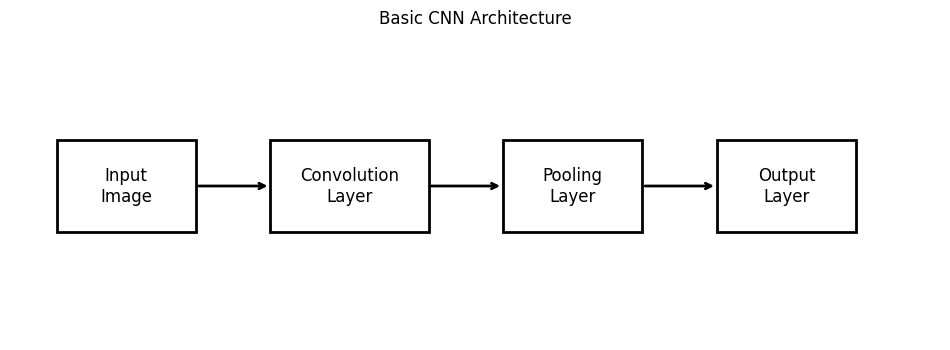

In [10]:
# 3.Draw the architecture diagram of a basic CNN (on paper or using a tool like draw.io) showing input layer, one convolutional layer, one pooling layer, 
# and an output layer. Label each part and briefly describe its function in 1-2 lines.

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(12, 4))

boxes = [
    (0.05, 0.35, 0.15, 0.3, "Input\nImage"),
    (0.28, 0.35, 0.17, 0.3, "Convolution\nLayer"),
    (0.53, 0.35, 0.15, 0.3, "Pooling\nLayer"),
    (0.76, 0.35, 0.15, 0.3, "Output\nLayer")
]

for x, y, w, h, text in boxes:
    ax.add_patch(Rectangle((x, y), w, h, fill=False, linewidth=2))
    ax.text(x + w/2, y + h/2, text,
            ha="center", va="center", fontsize=12)

ax.annotate("", xy=(0.28, 0.5), xytext=(0.20, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.annotate("", xy=(0.53, 0.5), xytext=(0.45, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.annotate("", xy=(0.76, 0.5), xytext=(0.68, 0.5),
            arrowprops=dict(arrowstyle="->", lw=2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.title("Basic CNN Architecture")
plt.show()

In [12]:
# 4.Write a function in Python that takes an image array and returns a new array where each pixel is replaced by the maximum value in its 2x2 local neighborhood (simulate max pooling).<br><br><em><strong>Constraint:</strong>
# Do not use any deep learning libraries like TensorFlow or PyTorch for this task.</em>

import numpy as np

def max_pooling(image):

    rows, cols = image.shape

    output = np.zeros((rows // 2, cols // 2))

    for i in range(0, rows - 1, 2):
        for j in range(0, cols - 1, 2):

            region = image[i:i+2, j:j+2]

            output[i//2, j//2] = np.max(region)

    return output


In [14]:
image = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
])

result = max_pooling(image)

print("Original Image:")
print(image)

print("\nAfter 2x2 Max Pooling:")
print(result)

Original Image:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

After 2x2 Max Pooling:
[[ 6.  8.]
 [14. 16.]]


In [ ]:
# 5.Explain with a real-world example from Instagram or Zomato how translation invariance in CNNs is useful. Write 2-3 sentences connecting it to how these apps recognize
# faces or food items even if they appear in different positions in the image.

Translation invariance allows CNNs to recognize the same object even when its position changes in an image. For example, Instagram can detect 
facial features at different positions, while Zomato can recognize food features even when the food is placed on different sides of a photo.